# Autor:
ROJAS MARTINEZ JONATHAN FRANCISCO

### Descripción del Problema
Este es un problema de **aprendizaje automático supervisado de clasificación multiclase**. 

El objetivo es clasificar imágenes en categorías específicas y discretas (Cartón, Vidrio, Metal, Papel, Plástico o Basura). No corresponde a regresión porque no estamos buscando predecir un valor numérico continuo, sino asignar una etiqueta categórica a una matriz de píxeles.

### Diseño de la Arquitectura CNN Propuesta
Para resolver este problema, se propone una Red Neuronal Convolucional con la siguiente arquitectura base:

* **Número de capas convolucionales:** 3 capas.
* **Número de filtros por capa:** 32 en la primera, 64 en la segunda y 128 en la tercera.
* **Tamaño de los filtros:** $3 \times 3$.
* **Capas de Max Pooling:** 3 capas (una ubicada después de cada capa convolucional) con un tamaño de ventana de $2 \times 2$.
* **Función de activación:** ReLU (Rectified Linear Unit) para las capas ocultas y Softmax para la capa de salida.
* **Capa de salida:** 1 capa densa (Fully Connected) compuesta por 6 neuronas (una por cada clase de residuo del dataset).

### Explicación de las Capas

* **Convolucional:** Aplica una serie de filtros o *kernels* matemáticos sobre la imagen para detectar y extraer características espaciales locales, tales como bordes, texturas y formas geométricas básicas.
* **ReLU:** Introduce no linealidad al modelo transformando cualquier valor negativo de las características a cero. Esto permite que la red aprenda patrones complejos y mitiga el problema del desvanecimiento del gradiente.
* **Max Pooling:** Reduce la dimensionalidad espacial (ancho y alto) de los mapas de características reteniendo únicamente el valor máximo de cada región. Esto disminuye la carga computacional y ayuda a que el modelo identifique características sin importar su posición exacta en la imagen.
* **Flatten:** Aplane el tensor multidimensional resultante de las capas anteriores convirtiéndolo en un vector unidimensional simple. Esto es necesario para poder conectar la salida de las convoluciones con las neuronas tradicionales.
* **Fully Connected:** Es una capa densa estándar donde todas las neuronas están conectadas a la capa anterior. Se encarga de combinar las características extraídas y aplanadas para realizar la clasificación final.

### Configuración de Entrenamiento y Evaluación

* **Función de pérdida:** **Sparse Categorical Crossentropy** (Entropía Cruzada Categórica Dispersa). Es la ideal para clasificación multiclase cuando las etiquetas se proveen como números enteros (0 a 5) en lugar de formato *One-Hot Encoding*.
* **Optimizador:** **Adam** (Adaptive Moment Estimation). Es eficiente computacionalmente, requiere poca memoria y adapta automáticamente la tasa de aprendizaje durante el proceso.
* **Métricas de evaluación:** La métrica principal será la **Exactitud (Accuracy)** para saber el porcentaje global de aciertos. De manera secundaria, se puede usar el **F1-Score** a través de un reporte de clasificación para evaluar el balance entre falsos positivos y falsos negativos en cada tipo de residuo individual.

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Rescaling
from tensorflow.keras.preprocessing import image
import numpy as np
import urllib.request
import os

### División del Conjunto de Datos

* Se asigna el **80% al conjunto de Entrenamiento** para proporcionar la mayor cantidad de datos posibles al modelo, permitiendo que la red neuronal convolucional ajuste sus pesos correctamente y aprenda a extraer las características visuales (bordes, texturas) de cada tipo de residuo de manera robusta. 
* El **20% restante se asigna al conjunto de Validación**, el cual se reserva de manera aislada durante el entrenamiento. Esto permite evaluar el rendimiento de la red al final de cada época con imágenes que no ha visto antes, lo que es vital para monitorear la exactitud del modelo en datos nuevos y detectar a tiempo si ocurre sobreajuste (overfitting).

In [19]:
# Config del dataset y el dataset
directorio_datos = 'dataset-resized'
tamaño_lote = 32
altura_img = 384
anchura_img = 512
# Entrenamiento
train_dataset = tf.keras.utils.image_dataset_from_directory(
    directorio_datos,
    validation_split=0.2, # 80% para entrenamiento
    subset="training",
    seed=123,
    image_size=(altura_img, anchura_img),
    batch_size=tamaño_lote
)

# Validacion
val_dataset = tf.keras.utils.image_dataset_from_directory(
    directorio_datos,
    validation_split=0.2, # 20% para validación
    subset="validation",
    seed=123,
    image_size=(altura_img, anchura_img),
    batch_size=tamaño_lote
)
# Extraer los nombres de las clases detectadas
clases_detectadas = train_dataset.class_names
print(f"Clases detectadas en las carpetas: {clases_detectadas}")

# Diccionario para traducir el resultado al español
traduccion_clases = {
    'cardboard': 'Cartón',
    'glass': 'Vidrio',
    'metal': 'Metal',
    'paper': 'Papel',
    'plastic': 'Plástico',
    'trash': 'Basura'
}

Found 2527 files belonging to 6 classes.
Using 2022 files for training.


Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Clases detectadas en las carpetas: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [20]:

# Diseño de la Arquitectura CNN
modelo_cnn = Sequential([
    # Capa de Normalización (escala los píxeles de 0-255 a 0-1 automáticamente)
    Rescaling(1./255, input_shape=(altura_img, anchura_img, 3)),
    
    # Capa Convolucional 1 + Max Pooling
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Capa Convolucional 2 + Max Pooling
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Capa Convolucional 3 + Max Pooling
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Transición a Fully Connected
    Flatten(),
    
    # Reducción de sobreajuste y Capa Oculta Densa
    Dropout(0.5),
    Dense(128, activation='relu'),
    
    # Capa de Salida (6 clases)
    Dense(6, activation='softmax')
])


In [21]:
# Compilación del modelo
modelo_cnn.compile(optimizer='adam', 
                   loss='sparse_categorical_crossentropy', 
                   metrics=['accuracy'])

print("\n=== Arquitectura de la CNN ===")
modelo_cnn.summary()

# Entrenamiento del modelo (configurado a 10 épocas para prueba, puedes subirlo)
print("\nIniciando el entrenamiento del modelo...")
history = modelo_cnn.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)


=== Arquitectura de la CNN ===


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 384, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 382, 510, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 191, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 189, 253, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 94, 126, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 92, 124, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 46, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 365056)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 365056)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    46,727,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,821,318 (178.61 MB)

 Trainable params: 46,821,318 (178.61 MB)

 Non-trainable params: 0 (0.00 B)


Iniciando el entrenamiento del modelo...
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.3289 - loss: 1.9720 - val_accuracy: 0.4198 - val_loss: 1.3790
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.4990 - loss: 1.2464 - val_accuracy: 0.5624 - val_loss: 1.1962
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.6207 - loss: 1.0155 - val_accuracy: 0.6257 - val_loss: 1.0921
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.7008 - loss: 0.8144 - val_accuracy: 0.5366 - val_loss: 1.3821
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.7893 - loss: 0.5900 - val_accuracy: 0.6139 - val_loss: 1.3245
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.8793 - loss: 0.3546 - val_accuracy: 0.5822 - val_loss: 1.6951
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.9031 - loss: 0.2882 - val_accuracy: 0.5465 - val_loss: 1.9863
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.9273

In [26]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Métricas para evaluar el modelo

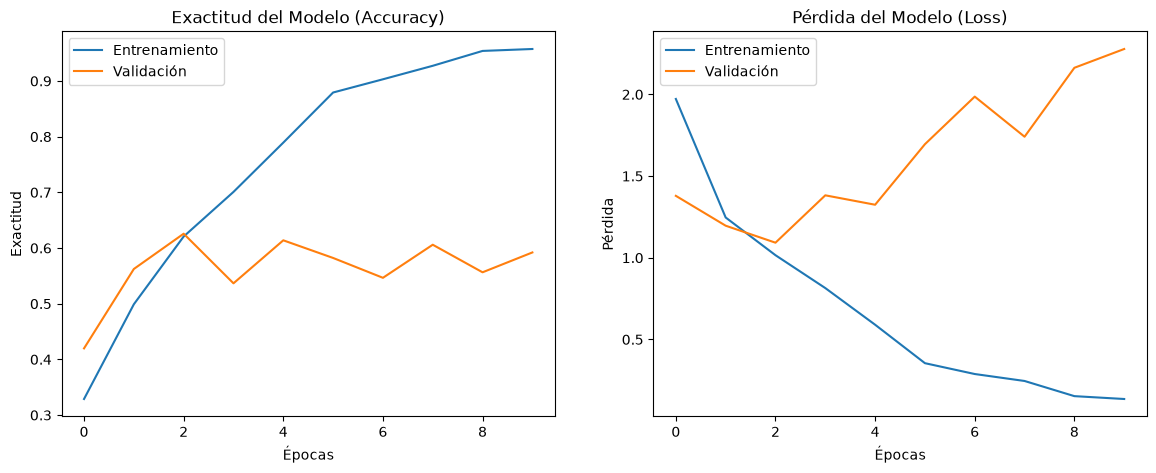


Generando predicciones sobre el conjunto de validación...
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 282ms/step

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

      Cartón       0.17      0.17      0.17        83
      Vidrio       0.19      0.20      0.20       103
       Metal       0.26      0.12      0.16        78
       Papel       0.29      0.35      0.32       124
    Plástico       0.19      0.23      0.21        88
      Basura       0.04      0.03      0.04        29

    accuracy                           0.21       505
   macro avg       0.19      0.18      0.18       505
weighted avg       0.21      0.21      0.21       505



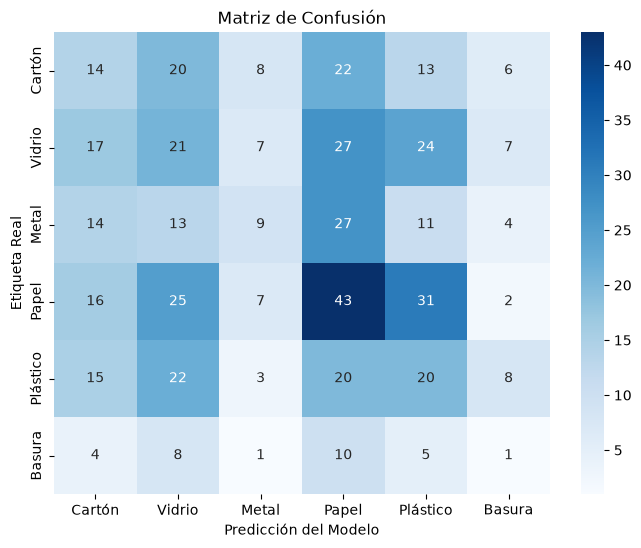

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ==========================================
# Curvas de Aprendizaje
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de Exactitud (Accuracy)
ax1.plot(history.history['accuracy'], label='Entrenamiento')
ax1.plot(history.history['val_accuracy'], label='Validación')
ax1.set_title('Exactitud del Modelo (Accuracy)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Exactitud')
ax1.legend()

# Gráfica de Pérdida (Loss)
ax2.plot(history.history['loss'], label='Entrenamiento')
ax2.plot(history.history['val_loss'], label='Validación')
ax2.set_title('Pérdida del Modelo (Loss)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Pérdida')
ax2.legend()

plt.show()

# ==========================================
# Obtener Predicciones para Evaluación
# ==========================================
print("\nGenerando predicciones sobre el conjunto de validación...")
# Extraer las imágenes y etiquetas reales del val_dataset
y_verdadero = np.concatenate([y for x, y in val_dataset], axis=0)
predicciones = modelo_cnn.predict(val_dataset)
y_predicho = np.argmax(predicciones, axis=1)

# Nombres de las clases en español
nombres_clases = ['Cartón', 'Vidrio', 'Metal', 'Papel', 'Plástico', 'Basura']

# ==========================================
# Reporte de Clasificación
# ==========================================
print("\n=== Reporte de Clasificación ===")
print(classification_report(y_verdadero, y_predicho, target_names=nombres_clases))

# ==========================================
# Matriz de Confusión
# ==========================================
matriz = confusion_matrix(y_verdadero, y_predicho)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.show()

In [28]:
# Ruta de la carpeta
carpeta_prueba = 'im_prueba'

print("=== Resultados de las Predicciones ===")
print("-" * 40)

if os.path.exists(carpeta_prueba):
    # Iterar sobre los archivos en la carpeta, ordenados alfabéticamente
    archivos = sorted(os.listdir(carpeta_prueba))
    
    for nombre_archivo in archivos:
        # Filtrar para procesar solo los archivos de imagen
        if nombre_archivo.lower().endswith(('.jpeg', '.jpg', '.png')):
            ruta_imagen = os.path.join(carpeta_prueba, nombre_archivo)
            
            # Cargar y preprocesar la imagen
            # Ajustamos al tamaño de entrada de la CNN (384x512)
            img = image.load_img(ruta_imagen, target_size=(384, 512))
            img_array = image.img_to_array(img)
            
            # Añadir la dimensión extra (batch) que requiere Keras: de (384, 512, 3) a (1, 384, 512, 3)
            img_array = np.expand_dims(img_array, axis=0)
            
            # Realizar la predicción
            # verbose=0 oculta la barra de progreso de predicción para mantener la consola limpia
            prediccion = modelo_cnn.predict(img_array, verbose=0) 
            indice_clase = np.argmax(prediccion[0])
            
            # Traducir el resultado al español
            clase_ingles = clases_detectadas[indice_clase]
            clase_espanol = traduccion_clases.get(clase_ingles, clase_ingles)
            
            # Resultado y comparando con el nombre del archivo
            print(f"{nombre_archivo} -> {clase_espanol}")
else:
    print(f"Error: No se encontró la carpeta '{carpeta_prueba}'. Verifica el nombre y la ubicación.")

=== Resultados de las Predicciones ===
----------------------------------------
basura.jpeg -> Metal
basura_001.png -> Papel
carton.jpeg -> Plástico
carton_001.jpeg -> Cartón
metal.jpeg -> Plástico
metal_001.jpg -> Metal
papel.jpeg -> Vidrio
plastico.jpeg -> Vidrio
plastico_0011.jpeg -> Vidrio
vidrio.jpeg -> Plástico
vidrio_001.jpg -> Papel


# Conclusión
Podemos ver que el algoritmo no logró el objetivo y el acurracy apenas llegó al 21%, vemos la gráfica de aprendizaje y vemos que esto es un caso de overfitting, la forma de solucionarlo es rotar, acercar, alejar los objetos que tenemos o agregar más imágenes para darle más variedad al modelo, pero debido a limitaciones computacionales, solamente se hizo hasta este punto, pero haciendo lo anterior lograremos un mejor resultado.